# 02 — NILS & CD Analysis

This notebook explores **NILS** (Normalised Image Log-Slope) and **CD** (Critical Dimension):
- NILS as image quality metric
- CD extraction via threshold
- SE-blur effect on NILS
- Process window basics (dose dependence)

**Physical background:** NILS is the key metric for image quality in lithography. Higher NILS → better CD control and wider process window.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from euvsimulator.pipeline import SimulationConfig, run_simulation
from euvsimulator.aerial.abbe import aerial_from_orders, nils

## 1. NILS Definition & Calculation

NILS = w · d(ln I)/dx evaluated at the nominal line edge, where w is the target CD.

Dimensionless metric — typical values:
- NILS > 4: excellent image
- NILS 2–4: acceptable
- NILS < 2: poor (SE blur dominated)

In [2]:
# Reference case: 32nm line in 64nm pitch
cfg = SimulationConfig(
    period_nm=64.0,
    line_width_nm=32.0,
    dose_mj_cm2=20.0,
    grid=256,
    se_blur_nm=0.0  # ideal, no blur
)

result = run_simulation(cfg)
print(f"Ideal case (no SE blur):")
print(f"  CD: {result.cd_nm:.2f} nm")
print(f"  NILS: {result.nils_value:.3f}")

Ideal case (no SE blur):
  CD: 27.62 nm
  NILS: 4.969


## 2. SE-Blur Effect on NILS

Secondary electrons spread the absorbed energy by a few nm (the chain's default is σ = 2.5 nm,
Thackeray et al. 2010). The `aerial_threshold` model thresholds the optical image directly and
ignores `se_blur_nm`, so this section applies the blur to the aerial image explicitly — the
`full_chem` chain applies it to the absorbed dose. In the full chain the acid diffusion during the
PEB (σ ≈ 7.9 nm by default) blurs more than the secondary electrons.

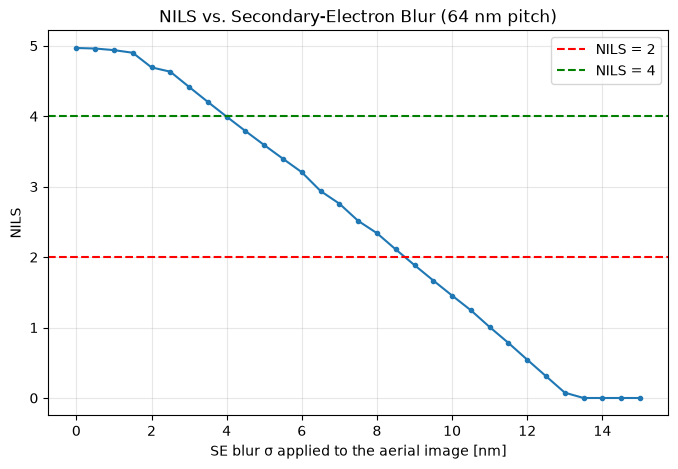

NILS at  0.0 nm blur: 4.969
NILS at  2.5 nm blur: 4.632
NILS at  5.0 nm blur: 3.590
NILS at  7.5 nm blur: 2.514
NILS at 10.0 nm blur: 1.454
NILS at 15.0 nm blur: 0.000


In [3]:
from euvsimulator.resist.exposure import gaussian_se_blur

# The aerial_threshold model ignores se_blur_nm, so the blur is applied to the image here.
cfg.se_blur_nm = 0.0
A = run_simulation(cfg).aerial_image
dx = cfg.period_nm / cfg.grid
half = cfg.grid // 2
lw_px = int(round(cfg.line_width_nm / dx))
thr = cfg.resist_threshold_norm * float(A.mean())  # the model's threshold at 20 mJ/cm²

se_blurs = np.arange(0.0, 15.01, 0.5)
nils_values = []
for blur in se_blurs:
    B = A if blur == 0 else gaussian_se_blur(A, sigma=float(blur), dx=dx)
    nils_values.append(nils(B, half, lw_px, dx, threshold=thr))  # 0 = no threshold crossing
nils_values = np.array(nils_values)

plt.figure(figsize=(8, 5))
plt.plot(se_blurs, nils_values, 'o-', ms=3)
plt.axhline(2.0, color='r', linestyle='--', label='NILS = 2')
plt.axhline(4.0, color='g', linestyle='--', label='NILS = 4')
plt.xlabel("SE blur σ applied to the aerial image [nm]")
plt.ylabel("NILS")
plt.title("NILS vs. Secondary-Electron Blur (64 nm pitch)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

for b in (0.0, 2.5, 5.0, 7.5, 10.0, 15.0):
    print(f"NILS at {b:4.1f} nm blur: {nils_values[int(round(b / 0.5))]:.3f}")

## 3. CD Extraction via Threshold

CD = width of the below-threshold region in the aerial image (positive-tone resist).

**Important:** The threshold is FIXED relative to the nominal-dose intensity → CD becomes dose-dependent (physically correct).

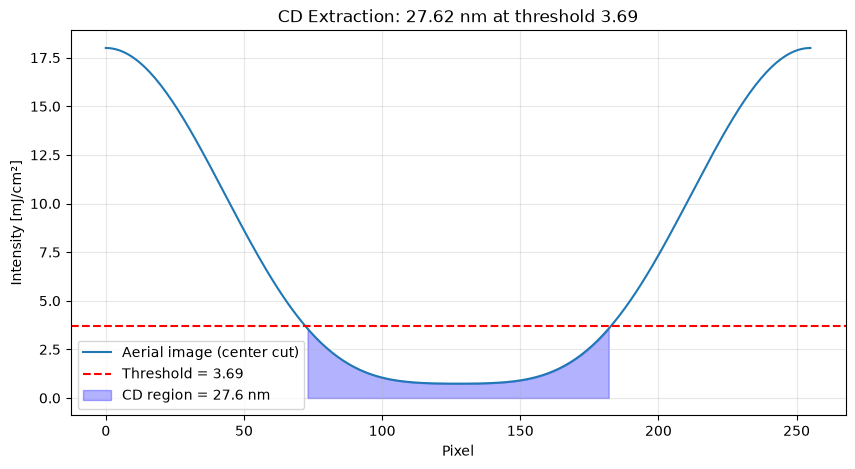

In [4]:
cfg.se_blur_nm = 5.0
result = run_simulation(cfg)
aerial = result.aerial_image
half = cfg.grid // 2
cut = aerial[half, :].numpy()

# Threshold computation (same as pipeline)
dc_level = float(aerial.mean())
nominal_dose = 20.0
threshold_val = cfg.resist_threshold_norm * dc_level * (nominal_dose / cfg.dose_mj_cm2)

plt.figure(figsize=(10, 5))
plt.plot(cut, label="Aerial image (center cut)")
plt.axhline(threshold_val, color='r', linestyle='--', label=f"Threshold = {threshold_val:.2f}")
plt.fill_between(range(len(cut)), 0, cut, where=(cut < threshold_val), alpha=0.3, color='blue', label=f"CD region = {result.cd_nm:.1f} nm")
plt.xlabel("Pixel")
plt.ylabel("Intensity [mJ/cm²]")
plt.title(f"CD Extraction: {result.cd_nm:.2f} nm at threshold {threshold_val:.2f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Dose Dependence of CD (Bossung Curve)

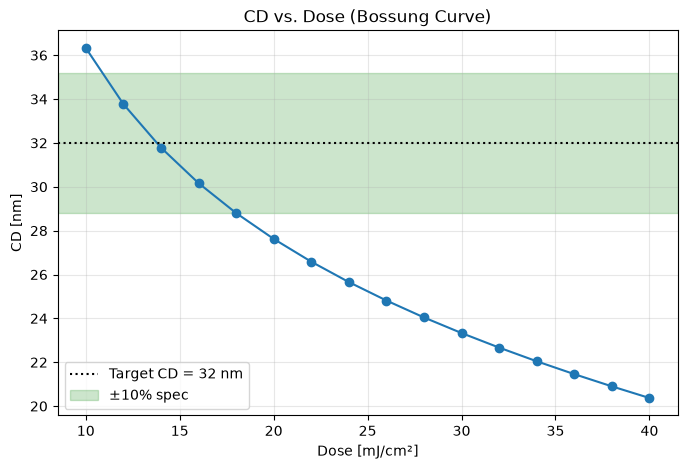

Dose-to-size: 14.0 mJ/cm² → CD = 31.79 nm


In [5]:
doses = np.linspace(10, 40, 16)
cds = []

for d in doses:
    cfg.dose_mj_cm2 = d
    r = run_simulation(cfg)
    cds.append(r.cd_nm)

cds = np.array(cds)

plt.figure(figsize=(8, 5))
plt.plot(doses, cds, 'o-')
plt.axhline(32.0, color='k', linestyle=':', label='Target CD = 32 nm')
plt.axhspan(32*0.9, 32*1.1, alpha=0.2, color='green', label='±10% spec')
plt.xlabel("Dose [mJ/cm²]")
plt.ylabel("CD [nm]")
plt.title("CD vs. Dose (Bossung Curve)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Find dose-to-size
idx = np.argmin(np.abs(cds - 32.0))
print(f"Dose-to-size: {doses[idx]:.1f} mJ/cm² → CD = {cds[idx]:.2f} nm")

## 5. Focus Dependence (Defocus Bossung)

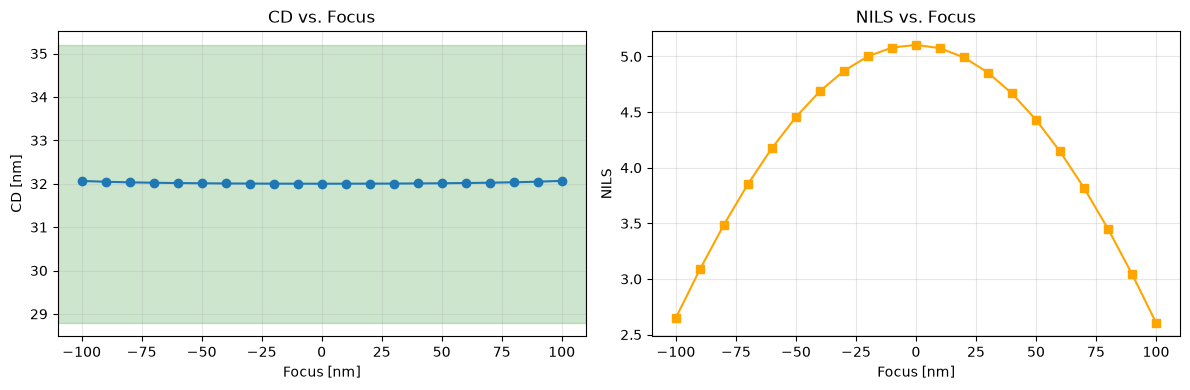

CD at focus 0: 32.00 nm; at -50 / +50 nm: 32.01 / 32.01 nm
NILS at focus 0: 5.104; at -50 / +50 nm: 4.456 / 4.431


In [6]:
cfg.dose_mj_cm2 = 13.76  # dose-to-size of this image (CD = 32 nm, Bossung curve above)
focuses = np.linspace(-100, 100, 21)
cds_focus = []
nils_focus = []

for f in focuses:
    cfg.focus_nm = f
    r = run_simulation(cfg)
    cds_focus.append(r.cd_nm)
    nils_focus.append(r.nils_value)

cds_focus = np.array(cds_focus)
nils_focus = np.array(nils_focus)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(focuses, cds_focus, 'o-')
ax1.axhspan(32*0.9, 32*1.1, alpha=0.2, color='green')
ax1.set_xlabel("Focus [nm]")
ax1.set_ylabel("CD [nm]")
ax1.set_title("CD vs. Focus")
ax1.grid(True, alpha=0.3)

ax2.plot(focuses, nils_focus, 's-', color='orange')
ax2.set_xlabel("Focus [nm]")
ax2.set_ylabel("NILS")
ax2.set_title("NILS vs. Focus")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

i0 = int(np.argmin(np.abs(focuses)))
i50 = [int(np.argmin(np.abs(focuses - f))) for f in (-50.0, 50.0)]
print(f"CD at focus 0: {cds_focus[i0]:.2f} nm; at -50 / +50 nm: {cds_focus[i50[0]]:.2f} / {cds_focus[i50[1]]:.2f} nm")
print(f"NILS at focus 0: {nils_focus[i0]:.3f}; at -50 / +50 nm: {nils_focus[i50[0]]:.3f} / {nils_focus[i50[1]]:.3f}")


## 6. Pitch Dependence (Resolution Limit)

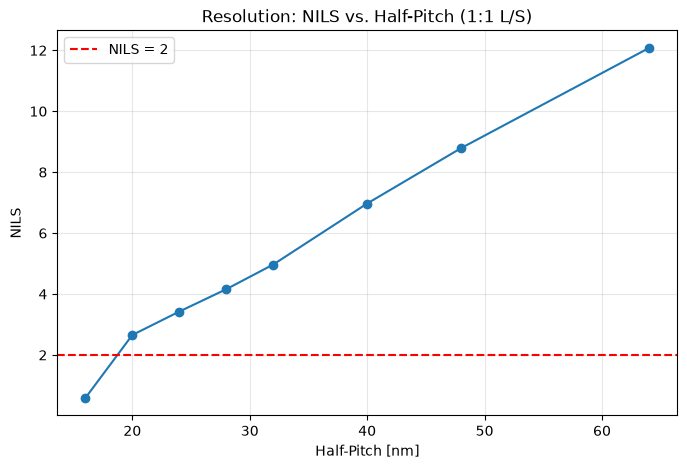

half-pitch   16 nm: NILS 0.59
half-pitch   20 nm: NILS 2.66
half-pitch   24 nm: NILS 3.42
half-pitch   28 nm: NILS 4.16
half-pitch   32 nm: NILS 4.97
half-pitch   40 nm: NILS 6.97
half-pitch   48 nm: NILS 8.79
half-pitch   64 nm: NILS 12.08
Rayleigh resolution (k1=0.33): 13.5 nm half-pitch


In [7]:
cfg.focus_nm = 0.0
cfg.dose_mj_cm2 = 20.0  # reference dose of the threshold model (threshold at half the image mean)
pitches = np.array([32, 40, 48, 56, 64, 80, 96, 128])
nils_pitch = []

for p in pitches:
    cfg.period_nm = float(p)
    cfg.line_width_nm = float(p) / 2  # 1:1 line:space
    r = run_simulation(cfg)
    nils_pitch.append(r.nils_value)

plt.figure(figsize=(8, 5))
plt.plot(pitches/2, nils_pitch, 'o-')
plt.axhline(2.0, color='r', linestyle='--', label='NILS = 2')
plt.xlabel("Half-Pitch [nm]")
plt.ylabel("NILS")
plt.title("Resolution: NILS vs. Half-Pitch (1:1 L/S)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

for hp, nv in zip(pitches / 2, nils_pitch):
    print(f"half-pitch {hp:4.0f} nm: NILS {nv:.2f}")

# Rayleigh estimate for comparison: half-pitch = k1 · λ / NA
k1 = 0.33
r_rayleigh = k1 * 13.5 / 0.33
print(f"Rayleigh resolution (k1={k1}): {r_rayleigh:.1f} nm half-pitch")

## Summary

| SE blur applied to the aerial image | 0 nm | 2.5 nm (chain default) | 5 nm | 10 nm |
|---|---|---|---|---|
| NILS (64 nm pitch, NA 0.33, σ 0.8) | 4.97 | 4.63 | 3.59 | 1.45 |

- **Blur lowers NILS quickly**: at 10 nm the 32 nm line is barely resolved, at 15 nm the image has
  no threshold crossing left. In the full chain the PEB acid diffusion (σ ≈ 7.9 nm) blurs more
  than the secondary electrons (2.5 nm).
- **CD depends on dose** through the fixed threshold; the dose-to-size of this image is 13.8 mJ/cm².
- **Focus**: at the dose-to-size the CD of this 1:1 line barely moves with focus (32.00 nm at
  focus 0, 32.01 nm at ±50 nm): the edge sits at an isofocal point. Defocus shows up as a
  shallower edge instead, NILS 5.10 → 4.46 / 4.43 at −50 / +50 nm.
- **Resolution**: with this conventional σ = 0.8 source NILS falls below 2 between 20 nm (2.66) and
  16 nm (0.59) half-pitch. The Rayleigh estimate k1·λ/NA with k1 = 0.33 gives 13.5 nm; this simple
  source does not reach it.